# 2 - Main figures

**Figure 2** - saccade count (% change from the pre-sound baseline) and
**Figure 3** - P(correct response), both as a function of saccade onset time
relative to sound onset, split by saccade-sound congruency.

2x2 grid: one panel per experiment. Each panel pairs a peri-saccadic line plot
(congruent vs incongruent, mean +/- SEM) with two amplitude x time heatmaps
sharing one colorbar; the heatmap spine colour marks the condition.

**Input**   `data_preprocessed/{EX_1,EX_9,EX_7,EX_3}/long_format_alt_all.csv`
**Outputs** `summaries/plots/` - `paper_fig_v2_peri.{png,pdf}`,
            `paper_fig_v2_pcorrect.{png,pdf}`

Significance tests and heatmap matrices are cached to
`summaries/cache/`; set `LOAD_CACHE = False` in the cache cells to recompute
after changing `METRIC`, `EXPERIMENTS`, or any `HM_*` parameter.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
import os
import sys
import importlib
import pickle

sys.path.insert(0, 'src')

import peri_sac
import config
import src.analysis_heatmap as analysis_heatmap

importlib.reload(peri_sac)
importlib.reload(config)
importlib.reload(analysis_heatmap)

from peri_sac import (
    calculate_running_window_metrics,
    plot_single_condition,
    test_pairwise_conditions,
    test_condition_vs_baseline,
    calculate_baseline_metrics_from_trials,
    apply_fdr_correction,
    plot_significance_bars,
    DEFAULT_METRICS,
    COLOR_PALETTES,
)
from config import (
    EXPERIMENT_CONFIGS,
    prepare_alternative_data,
    build_filter,
    METRIC_COLUMN_MAP,
    AMPLITUDE_UNIT_LABEL,
)
from src.analysis_heatmap import prepare_amplitude_time_heatmap, plot_amplitude_time_heatmap

%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Shared Configuration

In [3]:
# ====================================================================
# EXPERIMENTS
# ====================================================================

EXPERIMENTS = ['EX_1', 'EX_9', 'EX_7', 'EX_3']
EXPERIMENT_LABELS = [
    'Exp 1a. binaural-direction',
    'Exp 1b. binaural-direction',
    'Exp 2. monaural-direction',
    'Exp 3. monaural-pitch',
]

# ====================================================================
# TIME / WINDOW PARAMETERS  (shared by line plots and heatmaps)
# ====================================================================

SOUND_SELECTION  = 'both'
TIME_REFERENCE   = 'time_from_sound_to_sacc_start'
TIME_RANGE       = (-500, 1000)
WINDOW_SIZE      = 100
STEP_SIZE        = 25
BASELINE_RANGE   = (-500, 0)

MIN_CORRECTION_N = 5

OUTPUT_PATH = Path('summaries') / 'plots'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f'Experiments   : {EXPERIMENTS}')
print(f'Labels        : {EXPERIMENT_LABELS}')
print(f'Time reference: {TIME_REFERENCE}')
print(f'Baseline range: {BASELINE_RANGE} ms')

Experiments   : ['EX_1', 'EX_9', 'EX_7', 'EX_3']
Labels        : ['Exp 1a. binaural-direction', 'Exp 1b. binaural-direction', 'Exp 2. monaural-direction', 'Exp 3. monaural-pitch']
Time reference: time_from_sound_to_sacc_start
Baseline range: (-500, 0) ms


## Load Data & Compute Running-Window Metrics

In [4]:
experiment_data = {}

for EXPERIMENT in EXPERIMENTS:
    print(f'\n=== {EXPERIMENT} ===')

    data_raw = pd.read_csv(
        os.path.join(f'data_preprocessed/{EXPERIMENT}', 'long_format_alt_all.csv'),
        low_memory=False,
    )
    print(f'  Rows: {len(data_raw):,}  |  Subjects: {data_raw["id_subject"].nunique()}')

    data = prepare_alternative_data(data_raw, sound_selection=SOUND_SELECTION)
    analysis_filter     = build_filter(data)
    filter_consistent   = analysis_filter & (data['consistent'] == True)
    filter_inconsistent = analysis_filter & (data['consistent'] == False)

    sdt_column = EXPERIMENT_CONFIGS[EXPERIMENT].get('sdt_column')

    results_consistent = calculate_running_window_metrics(
        data, filter_consistent, TIME_REFERENCE,
        window_size=WINDOW_SIZE, step_size=STEP_SIZE,
        time_range=TIME_RANGE, baseline_range=BASELINE_RANGE,
        sdt_column=sdt_column, sdt_min_correction_n=MIN_CORRECTION_N,
    )
    results_inconsistent = calculate_running_window_metrics(
        data, filter_inconsistent, TIME_REFERENCE,
        window_size=WINDOW_SIZE, step_size=STEP_SIZE,
        time_range=TIME_RANGE, baseline_range=BASELINE_RANGE,
        sdt_column=sdt_column, sdt_min_correction_n=MIN_CORRECTION_N,
    )

    experiment_data[EXPERIMENT] = {
        'consistent':          results_consistent,
        'inconsistent':        results_inconsistent,
        'data':                data,
        'filter_consistent':   filter_consistent,
        'filter_inconsistent': filter_inconsistent,
        'sdt_column':          sdt_column,
    }
    print(f'  Windows: {results_consistent["window_center"].nunique()}  |  SDT col: {sdt_column}')

print('\nDone.')


=== EX_1 ===
  Rows: 248,227  |  Subjects: 52
  Windows: 61  |  SDT col: sound_direction

=== EX_9 ===
  Rows: 192,094  |  Subjects: 40
  Windows: 61  |  SDT col: sound_direction

=== EX_7 ===
  Rows: 188,481  |  Subjects: 40
  Windows: 61  |  SDT col: sound_direction

=== EX_3 ===
  Rows: 218,688  |  Subjects: 46
  Windows: 61  |  SDT col: sound_pitch

Done.


In [5]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Median RT and IQR per experiment
PERI_MEDIAN_RT    = {}
PERI_RT_QUARTILES = {}
_peri_subj_rt     = {}

for _exp in EXPERIMENTS:
    _data = experiment_data[_exp]['data']
    _fc   = experiment_data[_exp]['filter_consistent']
    _fi   = experiment_data[_exp]['filter_inconsistent']
    _rt   = _data[(_fc | _fi) & (_data['response_given'] == 1)]['rt']
    _rt   = _rt[_rt > 0]
    PERI_MEDIAN_RT[_exp]    = float(_rt.median())
    PERI_RT_QUARTILES[_exp] = (float(_rt.quantile(0.25)), float(_rt.quantile(0.75)))
    _peri_subj_rt[_exp] = (
        _data[(_fc | _fi) & (_data['response_given'] == 1) & (_data['rt'] > 0)]
        .groupby('id_subject')['rt'].median()
    )
    print(f'{_exp}: median RT = {PERI_MEDIAN_RT[_exp]:.0f} ms  '
          f'[Q1={PERI_RT_QUARTILES[_exp][0]:.0f}, Q3={PERI_RT_QUARTILES[_exp][1]:.0f}]  '
          f'n={len(_peri_subj_rt[_exp])}')

_exp_labels = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS
_pairs      = list(combinations(range(len(EXPERIMENTS)), 2))
_pvals_mw   = []
_mw_rows    = []
for i, j in _pairs:
    _u, _p = mannwhitneyu(
        _peri_subj_rt[EXPERIMENTS[i]], _peri_subj_rt[EXPERIMENTS[j]],
        alternative='two-sided')
    _mw_rows.append((EXPERIMENTS[i], EXPERIMENTS[j], _exp_labels[i], _exp_labels[j], _u, _p))
    _pvals_mw.append(_p)

_, _pvals_mw_corr, _, _ = multipletests(_pvals_mw, method='fdr_bh')

print(f"\nPairwise Mann-Whitney U  (FDR-corrected, per-subject median RT):")
for (_ei, _ej, _li, _lj, _u, _p_raw), _p_corr in zip(_mw_rows, _pvals_mw_corr):
    _sig = '*' if _p_corr < 0.05 else ' '
    print(f"  {_li}  vs  {_lj}"
          f"\n    U = {_u:.0f},  p = {_p_raw:.4f},  FDR-p = {_p_corr:.4f}  {_sig}")

EX_1: median RT = 634 ms  [Q1=517, Q3=799]  n=52
EX_9: median RT = 653 ms  [Q1=534, Q3=819]  n=40
EX_7: median RT = 556 ms  [Q1=456, Q3=709]  n=39
EX_3: median RT = 778 ms  [Q1=653, Q3=965]  n=46

Pairwise Mann-Whitney U  (FDR-corrected, per-subject median RT):
  Exp 1a. binaural-direction  vs  Exp 1b. binaural-direction
    U = 896,  p = 0.2600,  FDR-p = 0.2600   
  Exp 1a. binaural-direction  vs  Exp 2. monaural-direction
    U = 1421,  p = 0.0011,  FDR-p = 0.0013  *
  Exp 1a. binaural-direction  vs  Exp 3. monaural-pitch
    U = 343,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 1b. binaural-direction  vs  Exp 2. monaural-direction
    U = 1204,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 1b. binaural-direction  vs  Exp 3. monaural-pitch
    U = 334,  p = 0.0000,  FDR-p = 0.0000  *
  Exp 2. monaural-direction  vs  Exp 3. monaural-pitch
    U = 84,  p = 0.0000,  FDR-p = 0.0000  *


In [6]:
import math

def _make_3_ticks(vmin, vmax):
    vmid = (vmin + vmax) / 2
    span = abs(vmax - vmin)
    if span == 0:
        return [vmin]
    if max(abs(vmin), abs(vmax)) <= 1:
        lo  = math.ceil(vmin * 100) / 100
        hi  = math.floor(vmax * 100) / 100
        mid = round(vmid, 2)
    else:
        if span >= 50:
            scale = 10
        elif span >= 10:
            scale = 5
        elif span >= 1:
            scale = 1
        elif span >= 0.1:
            scale = 0.1
        else:
            scale = 0.05
        lo  = math.ceil(vmin / scale) * scale
        hi  = math.floor(vmax / scale) * scale
        mid = round(vmid / scale) * scale
    return sorted({lo, mid, hi})

## Figure: Peri-Saccadic Line + Heatmaps  (v2 layout)

2×2 grid — one panel per experiment. Within each panel:
- **Left**: peri-saccadic line plot (consistent vs inconsistent, mean ± SEM)
- **Right**: two amplitude×time heatmaps stacked vertically (consistent on top,
  inconsistent on bottom) with one shared colorbar. Each heatmap spine is drawn
  in the condition's line-plot color.

Change `METRIC` to generate the same layout for a different variable.

In [7]:
# ====================================================================
# FIGURE CONFIGURATION
# ====================================================================

METRIC = 'saccade_count_normalized'

LINE_YLIM = (-42, 42)
# LINE_YLIM = None
# LINE_YLIM = [(-60, 60), (-60, 60), (-40, 40), (-50, 50)]  # per experiment

# Panel dimensions
CELL_W_V2    = 8.5    # inches per panel (total)
CELL_H_V2    = 4.1    # inches per panel (total)

# Width split within each panel: line | heatmap | colorbar
LINE_W_RATIO = 2.5
HM_W_RATIO   = 1.3
CBAR_W_RATIO = 0.09

HM_SPINE_LW  = 2.5    # colored spine linewidth on heatmaps
FONTSIZE      = 12

LEGEND_POS = (-0.015, -0.02)  # bbox_to_anchor for legend in first panel

# Heatmap data parameters (changing any of these requires recomputing the cache)
HM_AMPLITUDE_COL      = METRIC_COLUMN_MAP['amplitude']
HM_AMPLITUDE_UNIT     = AMPLITUDE_UNIT_LABEL
HM_BINNING_METHOD     = 'quantile_presound'
HM_N_BINS             = 10
HM_PER_SUBJECT        = False
HM_PRESOUND_THRESHOLD = 0
HM_VLIM               = None
HM_TIME_REFERENCE     = TIME_REFERENCE
HM_TIME_RANGE         = TIME_RANGE
HM_BASELINE_RANGE     = BASELINE_RANGE
HM_WINDOW_SIZE        = WINDOW_SIZE * 2
HM_STEP_SIZE          = STEP_SIZE  * 2

print(f'Metric    : {METRIC}')
print(f'LINE_YLIM : {LINE_YLIM}')
print(f'HM bins   : {HM_N_BINS} ({HM_BINNING_METHOD})')
print(f'HM window : {HM_WINDOW_SIZE} ms  step: {HM_STEP_SIZE} ms')

Metric    : saccade_count_normalized
LINE_YLIM : (-42, 42)
HM bins   : 10 (quantile_presound)
HM window : 200 ms  step: 50 ms


In [8]:
# ====================================================================
# CACHE — precompute significance tests + heatmap matrices
# ====================================================================
# Set LOAD_CACHE = True to skip computation and load from disk.
# Set LOAD_CACHE = False (or delete the cache file) to recompute.
#
# Recompute when you change: METRIC, EXPERIMENTS, any HM_* parameter,
# TIME_REFERENCE, TIME_RANGE, BASELINE_RANGE, WINDOW_SIZE, STEP_SIZE.
# Display-only changes (FONTSIZE, CELL_W_V2, LINE_YLIM, …) never need
# a recompute — just re-run this cell with LOAD_CACHE = True and the
# plot cell below it.
# ====================================================================

LOAD_CACHE = True

CACHE_DIR  = Path('summaries') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / f'fig_v2_{METRIC}_{"_".join(EXPERIMENTS)}.pkl'

if LOAD_CACHE and CACHE_FILE.exists():
    with open(CACHE_FILE, 'rb') as _f:
        _cache = pickle.load(_f)
    sig_cache = _cache['sig']
    hm_cache  = _cache['hm']
    print(f'Loaded cache: {CACHE_FILE}')
    print(f'Experiments in cache: {list(sig_cache.keys())}')

else:
    sig_cache = {}
    hm_cache  = {}

    for exp_name in EXPERIMENTS:
        print(f'\n--- {exp_name} ---')
        ed           = experiment_data[exp_name]
        results_list = [ed['consistent'], ed['inconsistent']]
        analysis_filter = ed['filter_consistent'] | ed['filter_inconsistent']

        # Significance tests
        cols_keep = ['id_subject', 'window_center', METRIC]
        merged = results_list[0][cols_keep].rename(columns={METRIC: f'{METRIC}_cond0'})
        temp   = results_list[1][cols_keep].rename(columns={METRIC: f'{METRIC}_cond1'})
        merged = merged.merge(temp, on=['id_subject', 'window_center'], how='outer')

        sig   = {}
        tname = f'{METRIC}_cond0_vs_cond1'
        sig[tname] = []
        for wc in merged['window_center'].dropna().unique():
            wd = merged[merged['window_center'] == wc]
            r  = test_pairwise_conditions(wd, METRIC, '_cond0', '_cond1')
            r['window_center'] = wc
            sig[tname].append(r)

        for ci, filt in enumerate([ed['filter_consistent'], ed['filter_inconsistent']]):
            bd = calculate_baseline_metrics_from_trials(
                ed['data'][filt], BASELINE_RANGE, TIME_REFERENCE)
            tk = f'{METRIC}_cond{ci}_vs_baseline'
            sig[tk] = []
            for wc in merged['window_center'].dropna().unique():
                wd = merged[merged['window_center'] == wc]
                r  = test_condition_vs_baseline(
                    wd, bd, METRIC, metric_suffix=f'_cond{ci}',
                    baseline_range=BASELINE_RANGE, window_size=WINDOW_SIZE)
                r['window_center'] = wc
                sig[tk].append(r)

        # FDR corrected across all three comparisons at once: the family is
        # every test x every time window, not each comparison separately.
        sig_cache[exp_name] = apply_fdr_correction(sig)
        print('  significance done')

        # Heatmap data
        hm_cache[exp_name] = {}
        for consistency, label in [(True, 'consistent'), (False, 'inconsistent')]:
            print(f'  heatmap: {label} ...', end=' ', flush=True)
            hm_cache[exp_name][label] = prepare_amplitude_time_heatmap(
                data               = ed['data'],
                analysis_filter    = analysis_filter,
                amplitude_col      = HM_AMPLITUDE_COL,
                time_reference     = HM_TIME_REFERENCE,
                time_range         = HM_TIME_RANGE,
                baseline_range     = HM_BASELINE_RANGE,
                consistency        = consistency,
                window_size        = HM_WINDOW_SIZE,
                step_size          = HM_STEP_SIZE,
                binning_method     = HM_BINNING_METHOD,
                n_bins             = HM_N_BINS,
                per_subject        = HM_PER_SUBJECT,
                presound_threshold = HM_PRESOUND_THRESHOLD,
                metric             = METRIC,
                vlim               = HM_VLIM,
            )
            print('done')

    with open(CACHE_FILE, 'wb') as _f:
        pickle.dump({'sig': sig_cache, 'hm': hm_cache}, _f)
    print(f'\nSaved cache: {CACHE_FILE}')

Loaded cache: summaries\cache\fig_v2_saccade_count_normalized_EX_1_EX_9_EX_7_EX_3.pkl
Experiments in cache: ['EX_1', 'EX_9', 'EX_7', 'EX_3']


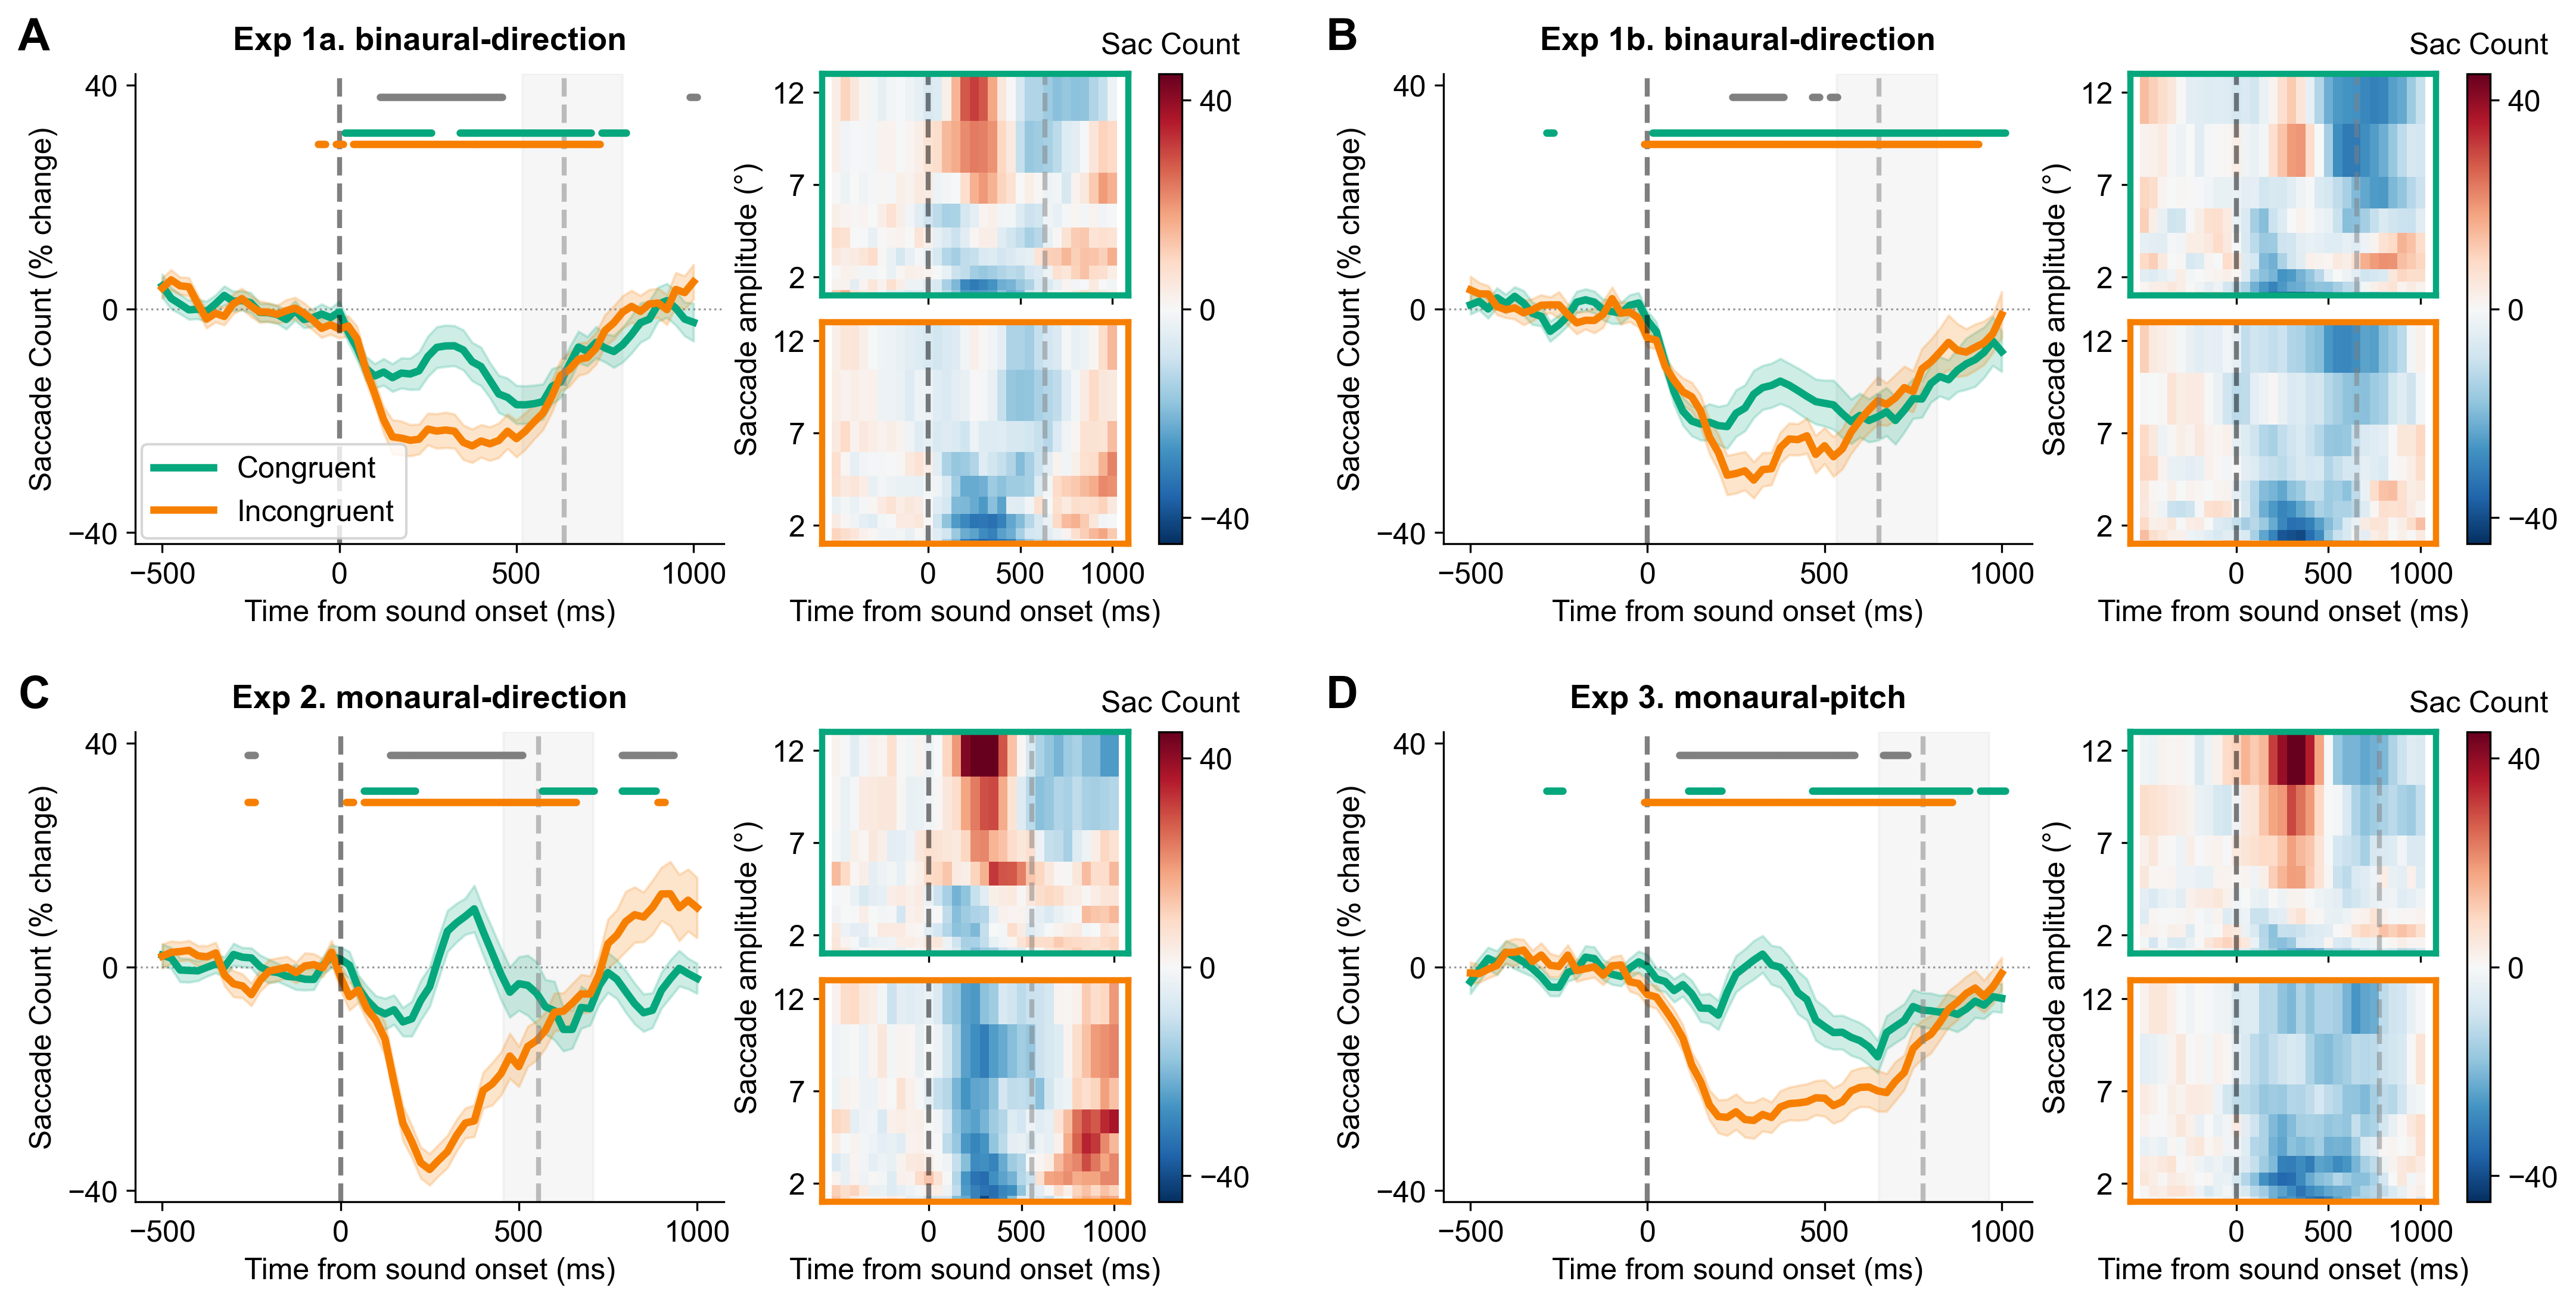

Done.


In [9]:
colors          = COLOR_PALETTES[2]   # [consistent_color, inconsistent_color]
condition_names = ('Congruent', 'Incongruent')
conditions_list = [('consistent', True), ('inconsistent', False)]
col_labels_fig  = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS
PANEL_LABELS    = ['A', 'B', 'C', 'D']

assert len(EXPERIMENTS) == 4, "v2 layout expects exactly 4 experiments (2×2 grid)"

fig_w = CELL_W_V2 * 2
fig_h = CELL_H_V2 * 2

fig = plt.figure(figsize=(fig_w, fig_h))

outer_gs = gridspec.GridSpec(
    2, 2,
    figure  = fig,
    hspace  = 0.40,
    wspace  = 0.25,
)

hm_ylabel = f'Saccade amplitude ({HM_AMPLITUDE_UNIT})'

for exp_idx, exp_name in enumerate(EXPERIMENTS):
    outer_row = exp_idx // 2
    outer_col = exp_idx % 2
    ed           = experiment_data[exp_name]
    results_list = [ed['consistent'], ed['inconsistent']]
    sig          = sig_cache[exp_name]

    # ── Panel layout ─────────────────────────────────────────────────
    # Level 1: [plots | colorbar]
    panel_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec = outer_gs[outer_row, outer_col],
        width_ratios = [LINE_W_RATIO + HM_W_RATIO, CBAR_W_RATIO],
        wspace       = 0.06,
    )

    # Level 2: [line | heatmaps]
    plots_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec  = panel_gs[0, 0],
        width_ratios  = [LINE_W_RATIO, HM_W_RATIO],
        height_ratios = [1, 1],
        wspace        = 0.22,   # gap between line plot and heatmaps
        hspace        = 0.12,
    )

    ax_line   = fig.add_subplot(plots_gs[0:2, 0])
    ax_hm_top = fig.add_subplot(plots_gs[0, 1])   # no sharex: set_xticks would leak back
    ax_hm_bot = fig.add_subplot(plots_gs[1, 1])
    ax_cbar   = fig.add_subplot(panel_gs[0, 1])

    # ── Line plot ─────────────────────────────────────────────────────
    for ci, res_df in enumerate(results_list):
        plot_single_condition(ax_line, res_df, METRIC, colors[ci], condition_names[ci])

    ax_line.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.5)
    exp_rt   = PERI_MEDIAN_RT.get(exp_name)
    exp_rt_q = PERI_RT_QUARTILES.get(exp_name)
    if exp_rt:
        ax_line.axvline(exp_rt, color='gray', linestyle='--', linewidth=2, alpha=0.5)
        if exp_rt_q:
            ax_line.axvspan(exp_rt_q[0], exp_rt_q[1], color='lightgray', alpha=0.2, zorder=0)

    ax_line.spines['top'].set_visible(False)
    ax_line.spines['right'].set_visible(False)
    ax_line.grid(False)
    ax_line.tick_params(axis='both', labelsize=FONTSIZE, labelbottom=True)
    for lbl in ax_line.get_xticklabels() + ax_line.get_yticklabels():
        lbl.set_fontfamily('Arial')
    ax_line.set_title(
        col_labels_fig[exp_idx], fontsize=FONTSIZE + 1, fontweight='bold',
        fontfamily='Arial', y=1.02)
    ax_line.set_ylabel(
        DEFAULT_METRICS.get(METRIC, {}).get('label', METRIC),
        fontsize=FONTSIZE, fontfamily='Arial')
    ax_line.set_xlabel('Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily='Arial')

    if LINE_YLIM is not None:
        _ylim = LINE_YLIM[exp_idx] if isinstance(LINE_YLIM, list) else LINE_YLIM
        if _ylim is not None:
            ax_line.set_ylim(_ylim)
    else:
        ax_line.autoscale_view()

    # Reference line: 0 for the % change count, mid-axis (baseline level) for P(correct)
    _ref_y = 0.0 if METRIC.startswith('saccade_count_normalized') else sum(ax_line.get_ylim()) / 2
    ax_line.axhline(_ref_y, color='grey', linestyle=':', linewidth=0.8, alpha=0.8, zorder=1)

    plot_significance_bars(ax_line, sig[f'{METRIC}_cond0_vs_cond1'], 0.05, 'grey', linewidth=3)
    baseline_start = 0.05 + 0.025 + 0.05
    for ci in range(2):
        tk = f'{METRIC}_cond{ci}_vs_baseline'
        if tk in sig:
            plot_significance_bars(
                ax_line, sig[tk], baseline_start + ci * 0.025, colors[ci], linewidth=3)

    ax_line.set_yticks(_make_3_ticks(*ax_line.get_ylim()))

    # Panel label (A/B/C/D) — top-left corner, above the experiment title
    ax_line.text(
        -0.2, 1.12, PANEL_LABELS[exp_idx],
        transform  = ax_line.transAxes,
        fontsize   = FONTSIZE + 6,
        fontweight = 'bold',
        fontfamily = 'Arial',
        va         = 'top',
        ha         = 'left',
    )

    if exp_idx == 0:
        legend_handles = [
            Line2D([0], [0], color=colors[0], linewidth=3, label=condition_names[0]),
            Line2D([0], [0], color=colors[1], linewidth=3, label=condition_names[1]),
        ]
        ax_line.legend(
            handles        = legend_handles,
            loc            = 'lower left',
            bbox_to_anchor = LEGEND_POS,
            prop           = {'family': 'Arial', 'size': FONTSIZE},
            frameon        = True,
        )

    # ── Heatmaps (from precomputed data) ─────────────────────────────
    for hm_row, (ax_hm, (cond_key, _)) in enumerate(
            zip([ax_hm_top, ax_hm_bot], conditions_list)):

        is_top  = (hm_row == 0)
        hm_data = hm_cache[exp_name][cond_key]

        # Top heatmap: route its unwanted colorbar to a tiny hidden inset
        if is_top:
            _dummy_cax = ax_hm.inset_axes([1.01, 0.0, 0.001, 1.0])
            _cax_arg   = _dummy_cax
        else:
            _cax_arg = ax_cbar

        plot_amplitude_time_heatmap(
            precomputed          = hm_data,
            amplitude_unit_label = HM_AMPLITUDE_UNIT,
            median_rt_line       = PERI_MEDIAN_RT.get(exp_name),
            ax                   = ax_hm,
            cax                  = _cax_arg,
        )

        if is_top:
            _dummy_cax.set_visible(False)

        # Colored spine = condition indicator
        for spine in ax_hm.spines.values():
            spine.set_edgecolor(colors[hm_row])
            spine.set_linewidth(HM_SPINE_LW)

        ax_hm.set_ylim(1, 13)
        ax_hm.set_yticks([2, 7, 12])

        # Sync xlim with line plot manually (no sharex, so set_xticks stays local)
        ax_hm.set_xlim(ax_line.get_xlim())
        ax_hm.set_xticks([0, 500, 1000])

        show_xlabel = not is_top
        ax_hm.tick_params(axis='both', labelsize=FONTSIZE, labelbottom=show_xlabel)
        for lbl in ax_hm.get_xticklabels() + ax_hm.get_yticklabels():
            lbl.set_fontfamily('Arial')
        ax_hm.xaxis.label.set_fontsize(FONTSIZE)
        ax_hm.xaxis.label.set_fontfamily('Arial')

        ax_hm.set_ylabel('')   # replaced by shared label below

        if show_xlabel:
            ax_hm.set_xlabel('Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily='Arial')
        else:
            ax_hm.set_xlabel('')

    # Single y-axis label centered between the two heatmaps.
    # y = -0.06 in ax_hm_top axes coords ≈ midpoint between the two equal-height axes
    # given hspace=0.12  (gap ≈ 0.12 axis-heights, so mid-gap is at -0.06).
    ax_hm_top.text(
        -0.24, -0.06, hm_ylabel,
        transform  = ax_hm_top.transAxes,
        fontsize   = FONTSIZE,
        fontfamily = 'Arial',
        va         = 'center',
        ha         = 'center',
        rotation   = 90,
        clip_on    = False,
    )

    ax_cbar.tick_params(labelsize=FONTSIZE)
    for lbl in ax_cbar.get_yticklabels():
        lbl.set_fontfamily('Arial')
    ax_cbar.title.set_fontfamily('Arial')
    ax_cbar.title.set_fontsize(FONTSIZE)

fig.savefig(
    OUTPUT_PATH / f'paper_fig_v2_{METRIC}.png',
    dpi=300, bbox_inches='tight',
)
fig.savefig(
    OUTPUT_PATH / f'paper_fig_v2_{METRIC}.pdf',
    bbox_inches='tight',
)
plt.show()
print('Done.')

In [10]:
# ====================================================================
# REPORTED VALUES  —  re-run after the figure cell to print stats
# ====================================================================
# Add more query blocks below as needed.
# ====================================================================

REPORT_METRIC = METRIC   # inherits from cell-fig-config (saccade_count_normalized)
REPORT_ALPHA  = 0.05

print(f"Metric : {REPORT_METRIC}")
print(f"Alpha  : {REPORT_ALPHA}\n")

# ── 1. Dip (min) in 0–300 ms  and  peak (max) in 0–450 ms ──────────
print("=" * 68)
print("DIP / PEAK  —  mean across subjects per window centre")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    ed = experiment_data[exp_name]
    print(f"\n  {exp_label}  ({exp_name})")

    for cond_label, res_df in [("Consistent",   ed["consistent"]),
                                ("Inconsistent", ed["inconsistent"])]:
        mean_by_t = res_df.groupby("window_center")[REPORT_METRIC].mean()

        # Dip: minimum in [0, 450] ms
        m_dip = (mean_by_t.index >= 0) & (mean_by_t.index <= 450)
        if m_dip.any():
            d_val  = mean_by_t[m_dip].min()
            d_time = mean_by_t[m_dip].idxmin()
            print(f"    {cond_label:15s}  dip  (0–450 ms) :  t = {d_time:5.0f} ms,  value = {d_val:+.3f}")

        # Peak: maximum in [50, 450] ms
        m_pk = (mean_by_t.index >= 50) & (mean_by_t.index <= 450)
        if m_pk.any():
            p_val  = mean_by_t[m_pk].max()
            p_time = mean_by_t[m_pk].idxmax()
            print(f"    {cond_label:15s}  peak (50–450 ms) :  t = {p_time:5.0f} ms,  value = {p_val:+.3f}")

# ── Recompute significance tests for all experiments ─────────────────
# All three comparisons are corrected together as a single family,
# exactly as in the cache cell that feeds the figure, so these p-values
# match the significance bars drawn above.
_all_sig_sc = {}
for exp_name in EXPERIMENTS:
    ed           = experiment_data[exp_name]
    results_list = [ed["consistent"], ed["inconsistent"]]

    cols_keep = ["id_subject", "window_center", REPORT_METRIC]
    merged = results_list[0][cols_keep].rename(columns={REPORT_METRIC: f"{REPORT_METRIC}_cond0"})
    temp   = results_list[1][cols_keep].rename(columns={REPORT_METRIC: f"{REPORT_METRIC}_cond1"})
    merged = merged.merge(temp, on=["id_subject", "window_center"], how="outer")

    sig = {}
    tname = f"{REPORT_METRIC}_cond0_vs_cond1"
    sig[tname] = []
    for wc in sorted(merged["window_center"].dropna().unique()):
        wd = merged[merged["window_center"] == wc]
        r  = test_pairwise_conditions(wd, REPORT_METRIC, "_cond0", "_cond1")
        r["window_center"] = wc
        sig[tname].append(r)

    for ci, filt in enumerate([ed["filter_consistent"], ed["filter_inconsistent"]]):
        bd = calculate_baseline_metrics_from_trials(
            ed["data"][filt], BASELINE_RANGE, TIME_REFERENCE)
        tk = f"{REPORT_METRIC}_cond{ci}_vs_baseline"
        sig[tk] = []
        for wc in sorted(merged["window_center"].dropna().unique()):
            wd = merged[merged["window_center"] == wc]
            r  = test_condition_vs_baseline(
                wd, bd, REPORT_METRIC, metric_suffix=f"_cond{ci}",
                baseline_range=BASELINE_RANGE, window_size=WINDOW_SIZE)
            r["window_center"] = wc
            sig[tk].append(r)

    _all_sig_sc[exp_name] = apply_fdr_correction(sig)


def _report_sig_clusters(sig_rows, alpha, step):
    sig_df = pd.DataFrame(sig_rows)
    sig_t  = sig_df.loc[sig_df["p_value_corrected"] < alpha, "window_center"].sort_values()
    if sig_t.empty:
        print("    No significant windows after FDR correction.")
        return
    # Cluster contiguous windows (gap > 2 steps → new cluster)
    clusters, start, prev = [], sig_t.iloc[0], sig_t.iloc[0]
    for t in sig_t.iloc[1:]:
        if t - prev > step * 2:
            clusters.append((start, prev))
            start = t
        prev = t
    clusters.append((start, prev))
    for c0, c1 in clusters:
        sub   = sig_df[(sig_df["window_center"] >= c0) &
                       (sig_df["window_center"] <= c1) &
                       (sig_df["p_value_corrected"] < alpha)]
        p_min = sub["p_value_corrected"].min()
        print(f"    t = {c0:.0f} – {c1:.0f} ms   (min FDR-p = {p_min:.4f})")
    print(f"    All sig. centres: {list(sig_t.astype(int))}")


# ── 2. Consistent vs. inconsistent ───────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  consistent vs. inconsistent  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_sc[exp_name][f"{REPORT_METRIC}_cond0_vs_cond1"], REPORT_ALPHA, STEP_SIZE)

# ── 3. Consistent vs. baseline ───────────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  consistent vs. baseline  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_sc[exp_name][f"{REPORT_METRIC}_cond0_vs_baseline"], REPORT_ALPHA, STEP_SIZE)

# ── 4. Inconsistent vs. baseline ─────────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  inconsistent vs. baseline  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_sc[exp_name][f"{REPORT_METRIC}_cond1_vs_baseline"], REPORT_ALPHA, STEP_SIZE)


Metric : saccade_count_normalized
Alpha  : 0.05

DIP / PEAK  —  mean across subjects per window centre

  Exp 1a. binaural-direction  (EX_1)
    Consistent       dip  (0–450 ms) :  t =   450 ms,  value = -15.217
    Consistent       peak (50–450 ms) :  t =   325 ms,  value = -6.606
    Inconsistent     dip  (0–450 ms) :  t =   375 ms,  value = -24.503
    Inconsistent     peak (50–450 ms) :  t =    50 ms,  value = -5.345

  Exp 1b. binaural-direction  (EX_9)
    Consistent       dip  (0–450 ms) :  t =   225 ms,  value = -21.046
    Consistent       peak (50–450 ms) :  t =    50 ms,  value = -9.657
    Inconsistent     dip  (0–450 ms) :  t =   300 ms,  value = -30.602
    Inconsistent     peak (50–450 ms) :  t =    50 ms,  value = -10.303

  Exp 2. monaural-direction  (EX_7)
    Consistent       dip  (0–450 ms) :  t =   175 ms,  value = -9.842
    Consistent       peak (50–450 ms) :  t =   375 ms,  value = +10.370
    Inconsistent     dip  (0–450 ms) :  t =   250 ms,  value = -36.215
  

## Figure: P(Correct)  (v2 layout)

Same 2×2 grid as Figure 1, for the P(correct response) metric.
Heatmap colour scale (and line-plot y-limits) are centred on each experiment's
baseline mean P(correct) (±25 %), matching the original single-panel figure.

In [11]:
# ====================================================================
# FIGURE CONFIGURATION — P(Correct)
# vcenter and vlim are auto-computed per experiment from the baseline period
# ====================================================================

METRIC = 'p_correct_response'

LEGEND_POS = (-0.015, -0.02)  # bbox_to_anchor for legend in first panel

HM_VCENT_PCR = {}
HM_VLIM_PCR  = {}

for _exp in EXPERIMENTS:
    _ed = experiment_data[_exp]
    _af = _ed['filter_consistent'] | _ed['filter_inconsistent']

    _bl_res = calculate_running_window_metrics(
        _ed['data'], _af, HM_TIME_REFERENCE,
        window_size=HM_WINDOW_SIZE, step_size=HM_STEP_SIZE,
        time_range=HM_TIME_RANGE, baseline_range=HM_BASELINE_RANGE,
    )
    _bl_vals = _bl_res.loc[
        (_bl_res['window_center'] >= HM_BASELINE_RANGE[0]) &
        (_bl_res['window_center'] <= HM_BASELINE_RANGE[1]),
        METRIC,
    ].dropna()

    _vcent  = float(_bl_vals.mean())
    _margin = 0.25 * _vcent
    HM_VCENT_PCR[_exp] = _vcent
    HM_VLIM_PCR[_exp]  = (_vcent - _margin, _vcent + _margin)
    print(f'{_exp}: vcenter={_vcent:.3f}  vlim=({_vcent - _margin:.3f}, {_vcent + _margin:.3f})')

LINE_YLIM = [HM_VLIM_PCR[exp] for exp in EXPERIMENTS]

print(f'\nMetric    : {METRIC}')
print(f'LINE_YLIM : {LINE_YLIM}')
print(f'HM bins   : {HM_N_BINS} ({HM_BINNING_METHOD})')
print(f'HM window : {HM_WINDOW_SIZE} ms  step: {HM_STEP_SIZE} ms')

EX_1: vcenter=0.563  vlim=(0.422, 0.704)
EX_9: vcenter=0.579  vlim=(0.434, 0.724)
EX_7: vcenter=0.683  vlim=(0.512, 0.854)
EX_3: vcenter=0.599  vlim=(0.450, 0.749)

Metric    : p_correct_response
LINE_YLIM : [(0.42216942409814856, 0.7036157068302475), (0.43438975052408735, 0.7239829175401457), (0.5122448388266393, 0.8537413980443987), (0.44957034426832043, 0.7492839071138674)]
HM bins   : 10 (quantile_presound)
HM window : 200 ms  step: 50 ms


In [12]:
# ====================================================================
# CACHE — precompute significance tests + heatmap matrices (P(Correct))
# ====================================================================
# Set LOAD_CACHE = True to skip computation and load from disk.
# Set LOAD_CACHE = False (or delete the cache file) to recompute.
#
# Recompute when you change: METRIC, EXPERIMENTS, any HM_* parameter,
# TIME_REFERENCE, TIME_RANGE, BASELINE_RANGE, WINDOW_SIZE, STEP_SIZE.
# Display-only changes (FONTSIZE, CELL_W_V2, LINE_YLIM, …) never need
# a recompute — just re-run this cell with LOAD_CACHE = True and the
# plot cell below it.
# ====================================================================

LOAD_CACHE = True

CACHE_DIR  = Path('summaries') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / f'fig_v2_{METRIC}_{"_".join(EXPERIMENTS)}.pkl'

if LOAD_CACHE and CACHE_FILE.exists():
    with open(CACHE_FILE, 'rb') as _f:
        _cache = pickle.load(_f)
    sig_cache = _cache['sig']
    hm_cache  = _cache['hm']
    print(f'Loaded cache: {CACHE_FILE}')
    print(f'Experiments in cache: {list(sig_cache.keys())}')

else:
    sig_cache = {}
    hm_cache  = {}

    for exp_name in EXPERIMENTS:
        print(f'\n--- {exp_name} ---')
        ed           = experiment_data[exp_name]
        results_list = [ed['consistent'], ed['inconsistent']]
        analysis_filter = ed['filter_consistent'] | ed['filter_inconsistent']

        # Significance tests
        cols_keep = ['id_subject', 'window_center', METRIC]
        merged = results_list[0][cols_keep].rename(columns={METRIC: f'{METRIC}_cond0'})
        temp   = results_list[1][cols_keep].rename(columns={METRIC: f'{METRIC}_cond1'})
        merged = merged.merge(temp, on=['id_subject', 'window_center'], how='outer')

        sig   = {}
        tname = f'{METRIC}_cond0_vs_cond1'
        sig[tname] = []
        for wc in merged['window_center'].dropna().unique():
            wd = merged[merged['window_center'] == wc]
            r  = test_pairwise_conditions(wd, METRIC, '_cond0', '_cond1')
            r['window_center'] = wc
            sig[tname].append(r)

        for ci, filt in enumerate([ed['filter_consistent'], ed['filter_inconsistent']]):
            bd = calculate_baseline_metrics_from_trials(
                ed['data'][filt], BASELINE_RANGE, TIME_REFERENCE)
            tk = f'{METRIC}_cond{ci}_vs_baseline'
            sig[tk] = []
            for wc in merged['window_center'].dropna().unique():
                wd = merged[merged['window_center'] == wc]
                r  = test_condition_vs_baseline(
                    wd, bd, METRIC, metric_suffix=f'_cond{ci}',
                    baseline_range=BASELINE_RANGE, window_size=WINDOW_SIZE)
                r['window_center'] = wc
                sig[tk].append(r)

        # FDR corrected across all three comparisons at once: the family is
        # every test x every time window, not each comparison separately.
        sig_cache[exp_name] = apply_fdr_correction(sig)
        print('  significance done')

        # Heatmap data
        hm_cache[exp_name] = {}
        for consistency, label in [(True, 'consistent'), (False, 'inconsistent')]:
            print(f'  heatmap: {label} ...', end=' ', flush=True)
            hm_cache[exp_name][label] = prepare_amplitude_time_heatmap(
                data               = ed['data'],
                analysis_filter    = analysis_filter,
                amplitude_col      = HM_AMPLITUDE_COL,
                time_reference     = HM_TIME_REFERENCE,
                time_range         = HM_TIME_RANGE,
                baseline_range     = HM_BASELINE_RANGE,
                consistency        = consistency,
                window_size        = HM_WINDOW_SIZE,
                step_size          = HM_STEP_SIZE,
                binning_method     = HM_BINNING_METHOD,
                n_bins             = HM_N_BINS,
                per_subject        = HM_PER_SUBJECT,
                presound_threshold = HM_PRESOUND_THRESHOLD,
                metric             = METRIC,
                vlim               = HM_VLIM_PCR[exp_name],
                vcenter            = HM_VCENT_PCR[exp_name],
            )
            print('done')

    with open(CACHE_FILE, 'wb') as _f:
        pickle.dump({'sig': sig_cache, 'hm': hm_cache}, _f)
    print(f'\nSaved cache: {CACHE_FILE}')

Loaded cache: summaries\cache\fig_v2_p_correct_response_EX_1_EX_9_EX_7_EX_3.pkl
Experiments in cache: ['EX_1', 'EX_9', 'EX_7', 'EX_3']


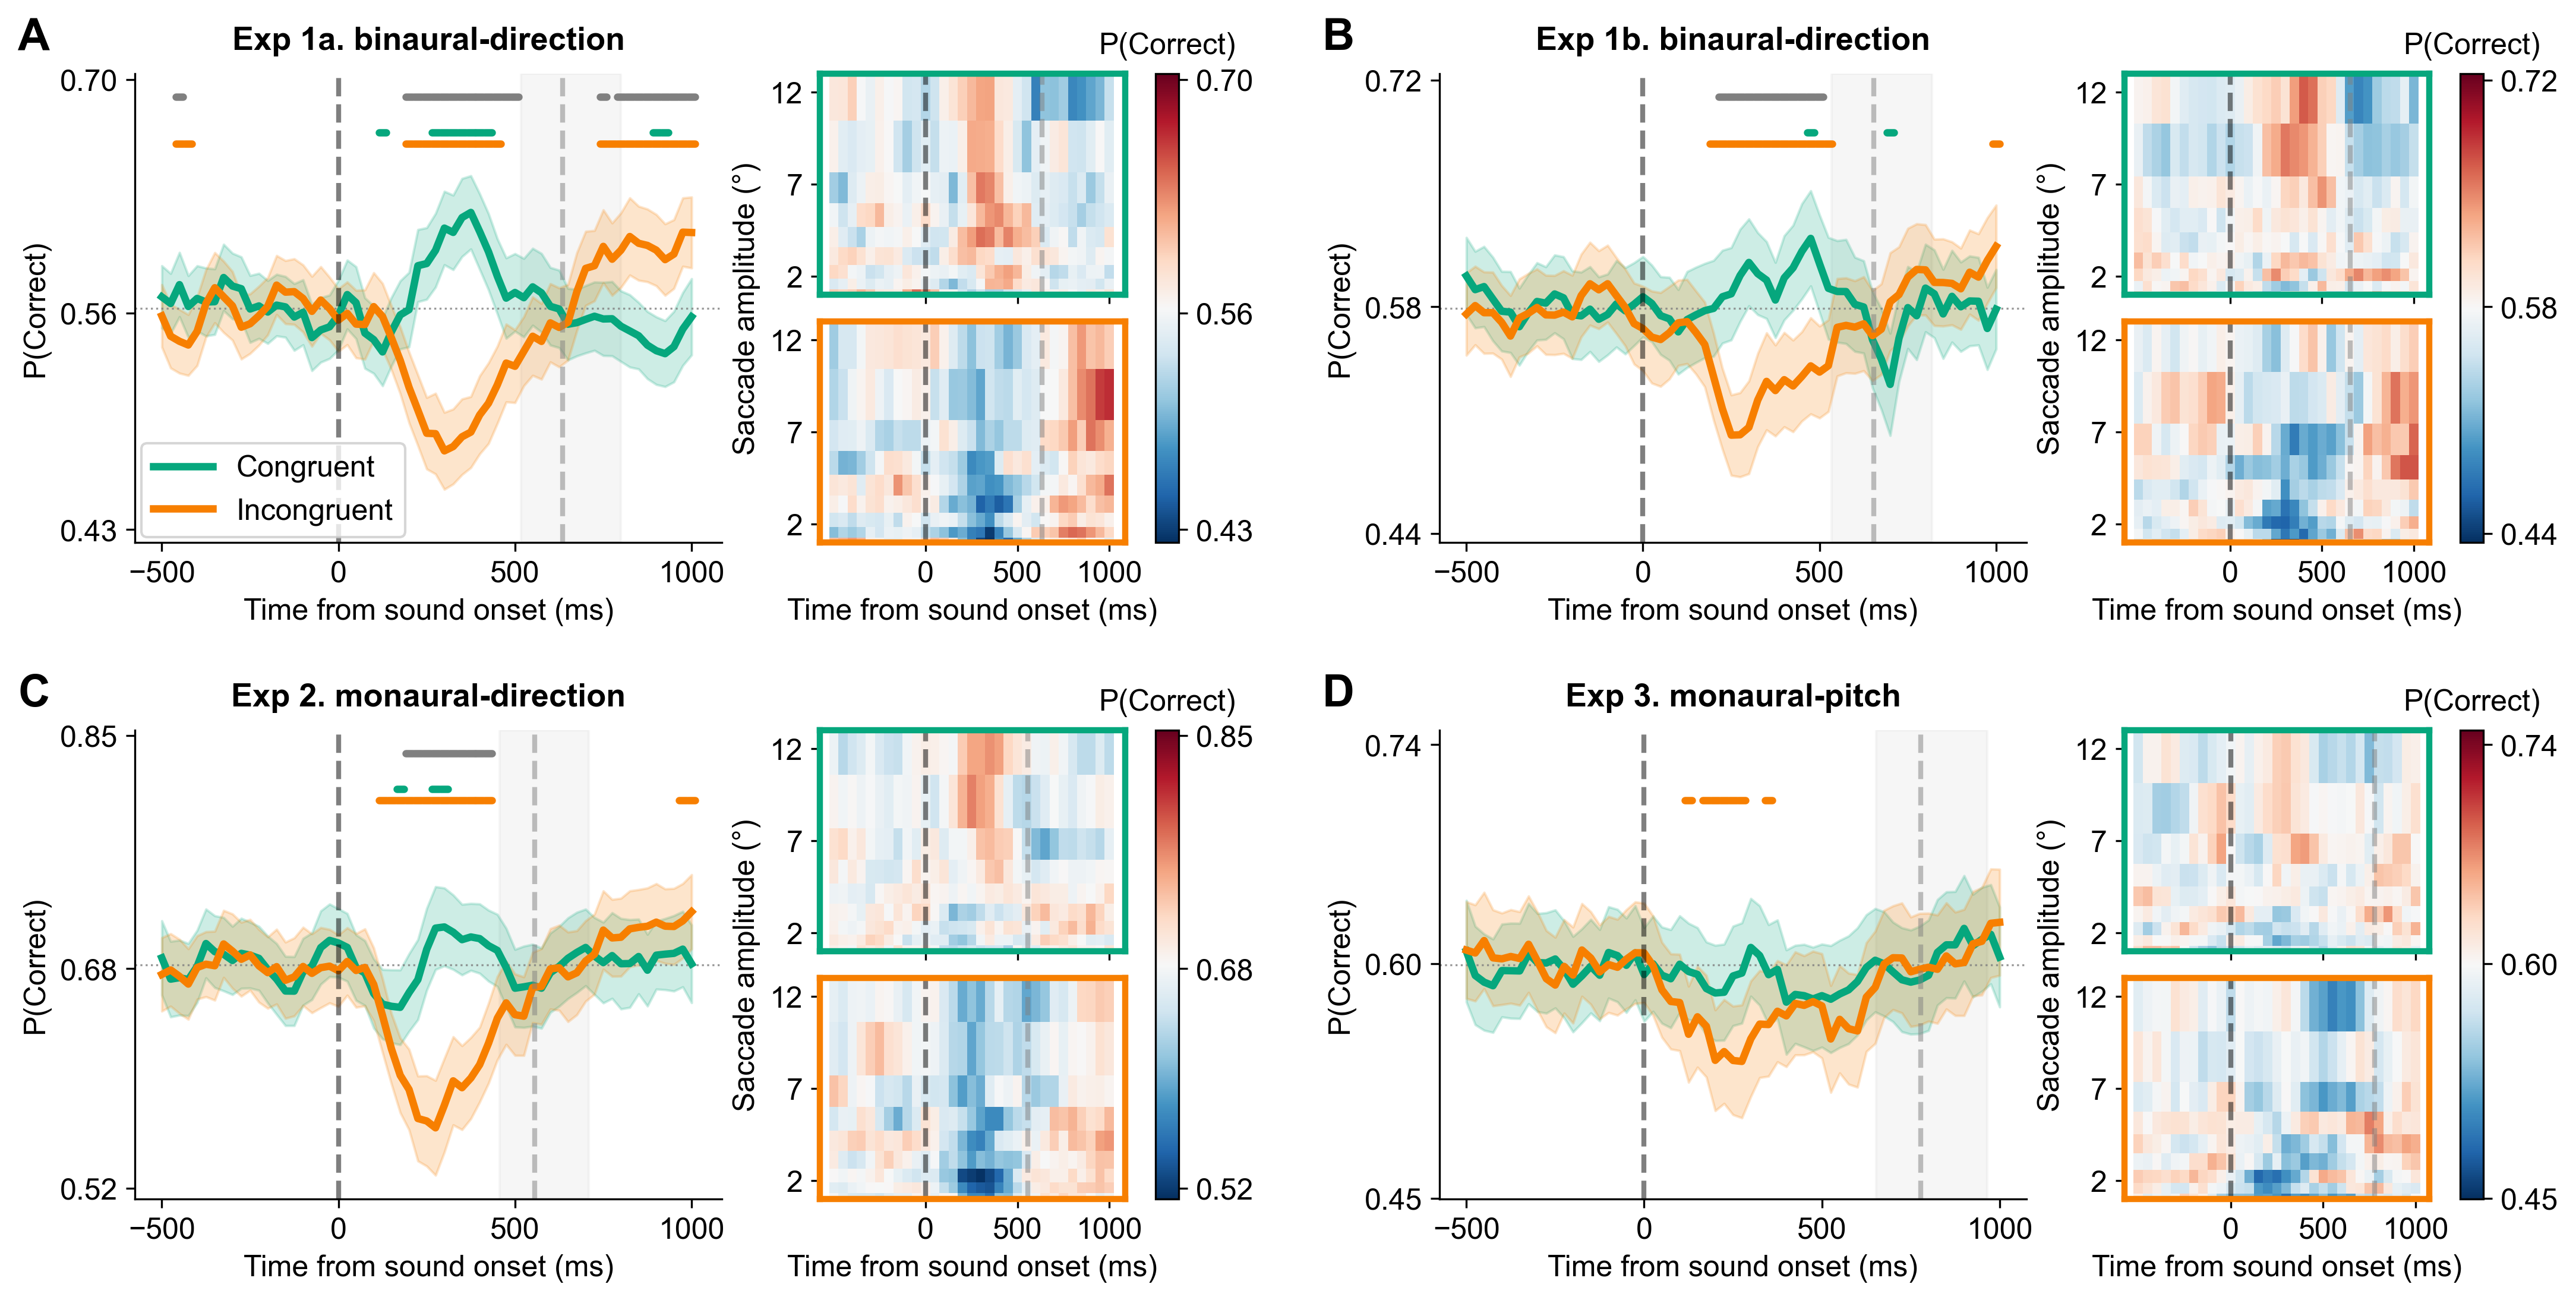

Done.


In [13]:
colors          = COLOR_PALETTES[2]   # [consistent_color, inconsistent_color]
condition_names = ('Congruent', 'Incongruent')
conditions_list = [('consistent', True), ('inconsistent', False)]
col_labels_fig  = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS
PANEL_LABELS    = ['A', 'B', 'C', 'D']

assert len(EXPERIMENTS) == 4, "v2 layout expects exactly 4 experiments (2×2 grid)"

fig_w = CELL_W_V2 * 2
fig_h = CELL_H_V2 * 2

fig = plt.figure(figsize=(fig_w, fig_h))

outer_gs = gridspec.GridSpec(
    2, 2,
    figure  = fig,
    hspace  = 0.40,
    wspace  = 0.25,
)

hm_ylabel = f'Saccade amplitude ({HM_AMPLITUDE_UNIT})'

for exp_idx, exp_name in enumerate(EXPERIMENTS):
    outer_row = exp_idx // 2
    outer_col = exp_idx % 2
    ed           = experiment_data[exp_name]
    results_list = [ed['consistent'], ed['inconsistent']]
    sig          = sig_cache[exp_name]

    # ── Panel layout ─────────────────────────────────────────────────
    # Level 1: [plots | colorbar]
    panel_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec = outer_gs[outer_row, outer_col],
        width_ratios = [LINE_W_RATIO + HM_W_RATIO, CBAR_W_RATIO],
        wspace       = 0.06,
    )

    # Level 2: [line | heatmaps]
    plots_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec  = panel_gs[0, 0],
        width_ratios  = [LINE_W_RATIO, HM_W_RATIO],
        height_ratios = [1, 1],
        wspace        = 0.22,   # gap between line plot and heatmaps
        hspace        = 0.12,
    )

    ax_line   = fig.add_subplot(plots_gs[0:2, 0])
    ax_hm_top = fig.add_subplot(plots_gs[0, 1])   # no sharex: set_xticks would leak back
    ax_hm_bot = fig.add_subplot(plots_gs[1, 1])
    ax_cbar   = fig.add_subplot(panel_gs[0, 1])

    # ── Line plot ─────────────────────────────────────────────────────
    for ci, res_df in enumerate(results_list):
        plot_single_condition(ax_line, res_df, METRIC, colors[ci], condition_names[ci])

    ax_line.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.5)
    exp_rt   = PERI_MEDIAN_RT.get(exp_name)
    exp_rt_q = PERI_RT_QUARTILES.get(exp_name)
    if exp_rt:
        ax_line.axvline(exp_rt, color='gray', linestyle='--', linewidth=2, alpha=0.5)
        if exp_rt_q:
            ax_line.axvspan(exp_rt_q[0], exp_rt_q[1], color='lightgray', alpha=0.2, zorder=0)

    ax_line.spines['top'].set_visible(False)
    ax_line.spines['right'].set_visible(False)
    ax_line.grid(False)
    ax_line.tick_params(axis='both', labelsize=FONTSIZE, labelbottom=True)
    for lbl in ax_line.get_xticklabels() + ax_line.get_yticklabels():
        lbl.set_fontfamily('Arial')
    ax_line.set_title(
        col_labels_fig[exp_idx], fontsize=FONTSIZE + 1, fontweight='bold',
        fontfamily='Arial', y=1.02)
    ax_line.set_ylabel(
        DEFAULT_METRICS.get(METRIC, {}).get('label', METRIC),
        fontsize=FONTSIZE, fontfamily='Arial')
    ax_line.set_xlabel('Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily='Arial')

    if LINE_YLIM is not None:
        _ylim = LINE_YLIM[exp_idx] if isinstance(LINE_YLIM, list) else LINE_YLIM
        if _ylim is not None:
            ax_line.set_ylim(_ylim)
    else:
        ax_line.autoscale_view()

    # Reference line: 0 for the % change count, mid-axis (baseline level) for P(correct)
    _ref_y = 0.0 if METRIC.startswith('saccade_count_normalized') else sum(ax_line.get_ylim()) / 2
    ax_line.axhline(_ref_y, color='grey', linestyle=':', linewidth=0.8, alpha=0.8, zorder=1)

    plot_significance_bars(ax_line, sig[f'{METRIC}_cond0_vs_cond1'], 0.05, 'grey', linewidth=3)
    baseline_start = 0.05 + 0.025 + 0.05
    for ci in range(2):
        tk = f'{METRIC}_cond{ci}_vs_baseline'
        if tk in sig:
            plot_significance_bars(
                ax_line, sig[tk], baseline_start + ci * 0.025, colors[ci], linewidth=3)

    ax_line.set_yticks(_make_3_ticks(*ax_line.get_ylim()))

    # Panel label (A/B/C/D) — top-left corner, above the experiment title
    ax_line.text(
        -0.2, 1.12, PANEL_LABELS[exp_idx],
        transform  = ax_line.transAxes,
        fontsize   = FONTSIZE + 6,
        fontweight = 'bold',
        fontfamily = 'Arial',
        va         = 'top',
        ha         = 'left',
    )

    if exp_idx == 0:
        legend_handles = [
            Line2D([0], [0], color=colors[0], linewidth=3, label=condition_names[0]),
            Line2D([0], [0], color=colors[1], linewidth=3, label=condition_names[1]),
        ]
        ax_line.legend(
            handles        = legend_handles,
            loc            = 'lower left',
            bbox_to_anchor = LEGEND_POS,
            prop           = {'family': 'Arial', 'size': FONTSIZE},
            frameon        = True,
        )

    # ── Heatmaps (from precomputed data) ─────────────────────────────
    for hm_row, (ax_hm, (cond_key, _)) in enumerate(
            zip([ax_hm_top, ax_hm_bot], conditions_list)):

        is_top  = (hm_row == 0)
        hm_data = hm_cache[exp_name][cond_key]

        # Top heatmap: route its unwanted colorbar to a tiny hidden inset
        if is_top:
            _dummy_cax = ax_hm.inset_axes([1.01, 0.0, 0.001, 1.0])
            _cax_arg   = _dummy_cax
        else:
            _cax_arg = ax_cbar

        plot_amplitude_time_heatmap(
            precomputed          = hm_data,
            amplitude_unit_label = HM_AMPLITUDE_UNIT,
            median_rt_line       = PERI_MEDIAN_RT.get(exp_name),
            ax                   = ax_hm,
            cax                  = _cax_arg,
        )

        if is_top:
            _dummy_cax.set_visible(False)

        # Colored spine = condition indicator
        for spine in ax_hm.spines.values():
            spine.set_edgecolor(colors[hm_row])
            spine.set_linewidth(HM_SPINE_LW)

        ax_hm.set_ylim(1, 13)
        ax_hm.set_yticks([2, 7, 12])

        # Sync xlim with line plot manually (no sharex, so set_xticks stays local)
        ax_hm.set_xlim(ax_line.get_xlim())
        ax_hm.set_xticks([0, 500, 1000])

        show_xlabel = not is_top
        ax_hm.tick_params(axis='both', labelsize=FONTSIZE, labelbottom=show_xlabel)
        for lbl in ax_hm.get_xticklabels() + ax_hm.get_yticklabels():
            lbl.set_fontfamily('Arial')
        ax_hm.xaxis.label.set_fontsize(FONTSIZE)
        ax_hm.xaxis.label.set_fontfamily('Arial')

        ax_hm.set_ylabel('')   # replaced by shared label below

        if show_xlabel:
            ax_hm.set_xlabel('Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily='Arial')
        else:
            ax_hm.set_xlabel('')

    # Single y-axis label centered between the two heatmaps.
    # y = -0.06 in ax_hm_top axes coords ≈ midpoint between the two equal-height axes
    # given hspace=0.12  (gap ≈ 0.12 axis-heights, so mid-gap is at -0.06).
    ax_hm_top.text(
        -0.24, -0.06, hm_ylabel,
        transform  = ax_hm_top.transAxes,
        fontsize   = FONTSIZE,
        fontfamily = 'Arial',
        va         = 'center',
        ha         = 'center',
        rotation   = 90,
        clip_on    = False,
    )

    ax_cbar.tick_params(labelsize=FONTSIZE)
    for lbl in ax_cbar.get_yticklabels():
        lbl.set_fontfamily('Arial')
    ax_cbar.title.set_fontfamily('Arial')
    ax_cbar.title.set_fontsize(FONTSIZE)

fig.savefig(
    OUTPUT_PATH / f'paper_fig_v2_{METRIC}.png',
    dpi=300, bbox_inches='tight',
)
fig.savefig(
    OUTPUT_PATH / f'paper_fig_v2_{METRIC}.pdf',
    bbox_inches='tight',
)
plt.show()
print('Done.')

In [14]:
# ====================================================================
# REPORTED VALUES  —  p(correct)
# re-run after the figure cell to print stats
# ====================================================================

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from itertools import combinations

_metric      = METRIC   # 'p_correct_response'
REPORT_ALPHA = 0.05

print(f"Metric : {_metric}")
print(f"Alpha  : {REPORT_ALPHA}\n")

# ── 0. Overall baseline per experiment (both conditions combined) ─────
print("=" * 68)
print(f"BASELINE MEAN ± SD  —  overall  ({BASELINE_RANGE[0]}–{BASELINE_RANGE[1]} ms)")
print("=" * 68)

_subj_bl_pcr = {}   # per-subject baseline means, used for t-tests below
for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    ed = experiment_data[exp_name]
    combined  = pd.concat([ed["consistent"], ed["inconsistent"]])
    # Per subject: mean over both conditions across baseline windows
    subj_bl   = (combined[
                    (combined["window_center"] >= BASELINE_RANGE[0]) &
                    (combined["window_center"] <= BASELINE_RANGE[1])
                 ]
                 .groupby("id_subject")[_metric]
                 .mean())
    _subj_bl_pcr[exp_name] = subj_bl
    print(f"  {exp_label:42s}  mean = {subj_bl.mean():.3f},  SD = {subj_bl.std():.3f}"
          f"  (n={len(subj_bl)})")

# Pairwise independent-samples t-tests (FDR corrected)
_exp_labels_pcr = EXPERIMENT_LABELS if EXPERIMENT_LABELS else EXPERIMENTS
_pairs_pcr      = list(combinations(range(len(EXPERIMENTS)), 2))
_pvals_t        = []
_t_rows         = []
for i, j in _pairs_pcr:
    _t, _p = ttest_ind(_subj_bl_pcr[EXPERIMENTS[i]], _subj_bl_pcr[EXPERIMENTS[j]])
    _t_rows.append((EXPERIMENTS[i], EXPERIMENTS[j],
                    _exp_labels_pcr[i], _exp_labels_pcr[j], _t, _p))
    _pvals_t.append(_p)

_, _pvals_t_corr, _, _ = multipletests(_pvals_t, method='fdr_bh')

print(f"\nPairwise t-tests  (FDR-corrected, per-subject baseline mean p(correct)):")
for (_ei, _ej, _li, _lj, _t, _p_raw), _p_corr in zip(_t_rows, _pvals_t_corr):
    _sig = '*' if _p_corr < 0.05 else ' '
    print(f"  {_li}  vs  {_lj}"
          f"\n    t = {_t:+.3f},  p = {_p_raw:.4f},  FDR-p = {_p_corr:.4f}  {_sig}")

# ── 1. Baseline mean + peak and dip values (per condition) ───────────
print(f"\n{'=' * 68}")
print("BASELINE  +  PEAK / DIP  —  mean across subjects per window centre")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    ed = experiment_data[exp_name]
    print(f"\n  {exp_label}  ({exp_name})")

    for cond_label, res_df in [("Consistent",   ed["consistent"]),
                                ("Inconsistent", ed["inconsistent"])]:
        mean_by_t = res_df.groupby("window_center")[_metric].mean()

        m_bl   = (mean_by_t.index >= BASELINE_RANGE[0]) & (mean_by_t.index <= BASELINE_RANGE[1])
        bl_val = float(mean_by_t[m_bl].mean()) if m_bl.any() else float("nan")
        print(f"    {cond_label:15s}  baseline ({BASELINE_RANGE[0]}–{BASELINE_RANGE[1]} ms) : "
              f" mean = {bl_val:.3f}")

        m_dip = (mean_by_t.index >= 0) & (mean_by_t.index <= 450)
        if m_dip.any():
            d_val   = mean_by_t[m_dip].min()
            d_time  = mean_by_t[m_dip].idxmin()
            d_delta = d_val - bl_val
            print(f"    {cond_label:15s}  dip  (0–450 ms)  :  t = {d_time:5.0f} ms,"
                  f"  value = {d_val:.3f},  Δbaseline = {d_delta:+.3f}")

        m_pk = (mean_by_t.index >= 0) & (mean_by_t.index <= 450)
        if m_pk.any():
            p_val   = mean_by_t[m_pk].max()
            p_time  = mean_by_t[m_pk].idxmax()
            p_delta = p_val - bl_val
            print(f"    {cond_label:15s}  peak (0–450 ms)  :  t = {p_time:5.0f} ms,"
                  f"  value = {p_val:.3f},  Δbaseline = {p_delta:+.3f}")

# ── Recompute significance tests for all experiments ─────────────────
_all_sig_pcr = {}
for exp_name in EXPERIMENTS:
    ed           = experiment_data[exp_name]
    results_list = [ed["consistent"], ed["inconsistent"]]

    cols_keep = ["id_subject", "window_center", _metric]
    merged = results_list[0][cols_keep].rename(columns={_metric: f"{_metric}_cond0"})
    temp   = results_list[1][cols_keep].rename(columns={_metric: f"{_metric}_cond1"})
    merged = merged.merge(temp, on=["id_subject", "window_center"], how="outer")

    sig = {}
    tname = f"{_metric}_cond0_vs_cond1"
    sig[tname] = []
    for wc in sorted(merged["window_center"].dropna().unique()):
        wd = merged[merged["window_center"] == wc]
        r  = test_pairwise_conditions(wd, _metric, "_cond0", "_cond1")
        r["window_center"] = wc
        sig[tname].append(r)

    for ci, filt in enumerate([ed["filter_consistent"], ed["filter_inconsistent"]]):
        bd = calculate_baseline_metrics_from_trials(
            ed["data"][filt], BASELINE_RANGE, TIME_REFERENCE)
        tk = f"{_metric}_cond{ci}_vs_baseline"
        sig[tk] = []
        for wc in sorted(merged["window_center"].dropna().unique()):
            wd = merged[merged["window_center"] == wc]
            r  = test_condition_vs_baseline(
                wd, bd, _metric, metric_suffix=f"_cond{ci}",
                baseline_range=BASELINE_RANGE, window_size=WINDOW_SIZE)
            r["window_center"] = wc
            sig[tk].append(r)

    _all_sig_pcr[exp_name] = apply_fdr_correction(sig)


def _report_sig_clusters(sig_rows, alpha, step):
    sig_df = pd.DataFrame(sig_rows)
    sig_t  = sig_df.loc[sig_df["p_value_corrected"] < alpha, "window_center"].sort_values()
    if sig_t.empty:
        print("    No significant windows after FDR correction.")
        return
    clusters, start, prev = [], sig_t.iloc[0], sig_t.iloc[0]
    for t in sig_t.iloc[1:]:
        if t - prev > step * 2:
            clusters.append((start, prev))
            start = t
        prev = t
    clusters.append((start, prev))
    for c0, c1 in clusters:
        sub   = sig_df[(sig_df["window_center"] >= c0) &
                       (sig_df["window_center"] <= c1) &
                       (sig_df["p_value_corrected"] < alpha)]
        p_min = sub["p_value_corrected"].min()
        print(f"    t = {c0:.0f} – {c1:.0f} ms   (min FDR-p = {p_min:.4f})")
    print(f"    All sig. centres: {list(sig_t.astype(int))}")


# ── 2. Consistent vs. inconsistent ───────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  consistent vs. inconsistent  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_pcr[exp_name][f"{_metric}_cond0_vs_cond1"], REPORT_ALPHA, STEP_SIZE)

# ── 3. Consistent vs. baseline ───────────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  consistent vs. baseline  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_pcr[exp_name][f"{_metric}_cond0_vs_baseline"], REPORT_ALPHA, STEP_SIZE)

# ── 4. Inconsistent vs. baseline ─────────────────────────────────────
print(f"\n{'=' * 68}")
print(f"SIGNIFICANT WINDOWS  —  inconsistent vs. baseline  (FDR p < {REPORT_ALPHA})")
print("=" * 68)

for exp_name, exp_label in zip(EXPERIMENTS, col_labels_fig):
    print(f"\n  {exp_label}  ({exp_name})")
    _report_sig_clusters(
        _all_sig_pcr[exp_name][f"{_metric}_cond1_vs_baseline"], REPORT_ALPHA, STEP_SIZE)


Metric : p_correct_response
Alpha  : 0.05

BASELINE MEAN ± SD  —  overall  (-500–0 ms)
  Exp 1a. binaural-direction                  mean = 0.563,  SD = 0.125  (n=51)
  Exp 1b. binaural-direction                  mean = 0.580,  SD = 0.144  (n=40)
  Exp 2. monaural-direction                   mean = 0.682,  SD = 0.152  (n=39)
  Exp 3. monaural-pitch                       mean = 0.600,  SD = 0.199  (n=46)

Pairwise t-tests  (FDR-corrected, per-subject baseline mean p(correct)):
  Exp 1a. binaural-direction  vs  Exp 1b. binaural-direction
    t = -0.606,  p = 0.5460,  FDR-p = 0.5944   
  Exp 1a. binaural-direction  vs  Exp 2. monaural-direction
    t = -4.102,  p = 0.0001,  FDR-p = 0.0005  *
  Exp 1a. binaural-direction  vs  Exp 3. monaural-pitch
    t = -1.121,  p = 0.2650,  FDR-p = 0.3976   
  Exp 1b. binaural-direction  vs  Exp 2. monaural-direction
    t = -3.078,  p = 0.0029,  FDR-p = 0.0087  *
  Exp 1b. binaural-direction  vs  Exp 3. monaural-pitch
    t = -0.534,  p = 0.5944,  FDR-